# StayPositive-DiffConvNet: DiffConvNet with Stay-Positive Last-Layer Retraining

**Base paper (architecture):** *Convolutional neural network framework for deepfake detection: A diffusion-based approach* — Pintelas & Livieris, CVIU 257 (2025) 104375

**Methodology applied on top:** *Stay-Positive: A Case for Ignoring Real Image Features in Fake Image Detection* — Sundara Rajan & Lee, ICML 2025 (arXiv:2502.07778)

---

## What this notebook does

This is a **new model** built on top of `deepfake-diffconvnet`. It adds a **third training phase** that retrains only the final linear layer under a non-negativity constraint, following Algorithm 1 of the Stay-Positive paper:

> *Avoiding negative weights in the final layer forces the detector to use only fake-image features and ignore real-image features (which are often spurious — compression artifacts, resizing, image-quality cues, etc.).*

### Why this should help our DiffConvNet

The DiffConvNet learns whatever discriminates real from fake in the training data. If the real folder contains any incidental artifacts (compression style, resizing pipeline, particular preprocessing the dataset author used), the classifier latches onto them. Stay-Positive removes the negative weights in `dn_fc` so the classifier can only fire on **fake** features — the *absence* of fake features now means real, instead of the *presence* of real features meaning real.

### How the Stay-Positive assumption maps onto our architecture

Stay-Positive requires that the feature going into the final linear layer is ReLU-activated (i.e. non-negative). In DiffConvNet:

```
... → dn_layer4 (ResNet BasicBlock ends in ReLU(out + identity)) → GAP → Dropout → fc
```

The output of a ResNet BasicBlock IS ReLU-activated, so its values are ≥ 0. GAP and Dropout preserve non-negativity. The assumption holds without architectural changes.

### Three-phase training pipeline

| Phase | What | Trainable | Output checkpoint |
|---|---|---|---|
| 1 | Fine-tune Base Network (ResNet18) | all | `sp_base_net_best.pth` |
| 2 | Build & fine-tune DiffConvNet end-to-end | diff_net + layer4 + fc | `sp_diffconvnet_stage1_best.pth` |
| 3 | **NEW** — Stay-Positive last-layer retraining | only fc, `w ← max(w,0)` after each step | `staypositive_diffconvnet_best.pth` |

All model files and checkpoints use the `sp_` / `staypositive_` prefix so this run cannot collide with the original DiffConvNet run.

---

## 1. Install & Import Dependencies

In [1]:
# !pip install -q timm scikit-learn matplotlib seaborn

import os
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.optim import Adam

from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce RTX 5080


## 2. Configuration

In [2]:
# ── Image ─────────────────────────────────────────────────────────
IMG_SIZE    = 224

# ── Diffusion ─────────────────────────────────────────────────────
N_DIFF      = 5            # diffusion iterations (paper default)
SPLIT_DEPTH = 1            # Depth-1 split (optimal per ablation)

# ── Training ──────────────────────────────────────────────────────
BATCH_SIZE       = 128
WEIGHT_DECAY_P1  = 5e-5
WEIGHT_DECAY_P2  = 1e-4
PATIENCE_ES      = 5

# ── Label smoothing ───────────────────────────────────────────────
LABEL_SMOOTHING  = 0.1

# ── Phase 1: fine-tune the base network ───────────────────────────
PHASE1_EPOCHS = 10
LR_PHASE1     = 1e-4

# ── Phase 2: fine-tune the full DiffConvNet ───────────────────────
PHASE2_EPOCHS = 50
LR_DIFFNET    = 5e-5
LR_LAYER4     = 1e-5
LR_FC         = 1e-4

# ── Phase 3: Stay-Positive last-layer retraining ──────────────────
# Following Algorithm 1 of Sundara Rajan & Lee 2025.
# Larger batch size (paper uses 1024) for stable last-layer optimisation.
# Backbone is frozen → memory cheap → big batch is fine.
SP_BATCH_SIZE   = 1024
SP_EPOCHS       = 30        # paper: ~15 epochs; we allow more headroom
SP_LR           = 1e-3      # higher LR since we are only learning one linear layer
SP_PATIENCE     = 8         # early stop on val-accuracy plateau
SP_WEIGHT_DECAY = 0.0       # paper does not regularise; we follow

print('Configuration loaded.')

Configuration loaded.


## 3. Dataset & DataLoader

Same `DeepFakeDataset` as the base notebook — Stay-Positive does **not** require a different dataset. The whole point is that we can apply it to data that may carry spurious real-side artifacts and the algorithm will reduce the detector's reliance on them.

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


class DeepFakeDataset(Dataset):
    """
    Expects:
        root/original/*.jpg  (label = 0)
        root/deepfake/*.jpg  (label = 1)
    """
    EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples   = []
        self.labels    = []

        for label, folder in enumerate(['original', 'deepfake']):
            folder_path = Path(root) / folder
            if not folder_path.exists():
                raise FileNotFoundError(f'Folder not found: {folder_path}')
            for p in sorted(folder_path.iterdir()):
                if p.suffix.lower() in self.EXTS:
                    self.samples.append(p)
                    self.labels.append(label)

        print(f'Dataset loaded: {len(self.samples)} images '
              f'({self.labels.count(0)} original, {self.labels.count(1)} fake)')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = Image.open(self.samples[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


print('Dataset class defined.')

Dataset class defined.


## 4. Model Architecture

Same DiffConvNet architecture as the base notebook. We do **not** modify the final layer — we simply train it differently in Phase 3. The Stay-Positive assumption (features into the final linear layer are ≥ 0 because the upstream BasicBlock ends in a ReLU) holds for free.

### 4.1 Diffusion Layer

In [4]:
class DiffLayer(nn.Module):
    """One diffusion step: Conv(3×3) + BN + ReLU."""
    def __init__(self, channels: int):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels,
                              kernel_size=3, padding=1, bias=False)
        self.bn   = nn.BatchNorm2d(channels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.relu(self.bn(self.conv(x)))


class DiffusionNetwork(nn.Module):
    """N independent DiffLayers; output is the average of all states (Eq. 6)."""
    def __init__(self, channels: int, n_iterations: int):
        super().__init__()
        self.n_iterations = n_iterations
        self.diff_layers = nn.ModuleList(
            [DiffLayer(channels) for _ in range(n_iterations)]
        )

    def forward(self, x0: torch.Tensor) -> torch.Tensor:
        states = [x0]
        x = x0
        for layer in self.diff_layers:
            x = layer(x)
            states.append(x)
        d = torch.stack(states, dim=0).mean(dim=0)
        return d


print('DiffLayer and DiffusionNetwork defined.')

DiffLayer and DiffusionNetwork defined.


### 4.2 Base Network (ResNet18 backbone)

In [5]:
class BaseNetwork(nn.Module):
    """
    ResNet18 backbone for binary deepfake detection.

    Note on Stay-Positive compatibility:
      The output of layer4 (a ResNet BasicBlock) ends in ReLU(out + identity),
      so the feature tensor entering GAP → Dropout → fc is element-wise ≥ 0.
      This satisfies the Stay-Positive assumption that the feature h into the
      final linear layer is non-negative — no architectural change needed.
    """
    def __init__(self, pretrained: bool = True, dropout_p: float = 0.5):
        super().__init__()
        backbone = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)

        self.layer0 = nn.Sequential(
            backbone.conv1, backbone.bn1,
            backbone.relu, backbone.maxpool
        )
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3

        self.dropout_mid = nn.Dropout2d(p=0.2)

        self.layer4 = backbone.layer4
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc     = nn.Linear(512, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.dropout_mid(x)
        x = self.layer4(x)
        x = self.gap(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x).squeeze(1)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer0(x)


print('BaseNetwork defined.')

BaseNetwork defined.


### 4.3 DiffConvNet

We expose a `features(x)` method that returns the activation entering `dn_fc`. Phase 3 needs this to cache features and do efficient last-layer retraining without re-running the whole backbone every iteration.

In [6]:
class DiffConvNet(nn.Module):
    """
    DiffConvNet = SN + DiffN + DN  (Eq. 3 in the paper)
    """
    def __init__(self, base_net: BaseNetwork, n_iterations: int = 5):
        super().__init__()
        self.sn = base_net.layer0
        self.diff_net = DiffusionNetwork(channels=64, n_iterations=n_iterations)

        self.dn_layer1   = base_net.layer1
        self.dn_layer2   = base_net.layer2
        self.dn_layer3   = base_net.layer3
        self.dn_drop_mid = base_net.dropout_mid
        self.dn_layer4   = base_net.layer4
        self.dn_gap      = base_net.gap
        self.dn_dropout  = base_net.dropout
        self.dn_fc       = base_net.fc

    def features(self, x: torch.Tensor) -> torch.Tensor:
        """
        Return the feature vector that enters dn_fc — i.e. h in the Stay-Positive paper.
        This is GAP(layer4(...)) flattened; it is element-wise >= 0.
        """
        x0  = self.sn(x)
        d   = self.diff_net(x0)
        out = self.dn_layer1(d)
        out = self.dn_layer2(out)
        out = self.dn_layer3(out)
        out = self.dn_drop_mid(out)
        out = self.dn_layer4(out)
        out = self.dn_gap(out).flatten(1)
        return out

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.features(x)
        out = self.dn_dropout(out)
        return self.dn_fc(out).squeeze(1)


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Sanity check
bn_test  = BaseNetwork(pretrained=False)
dcn_test = DiffConvNet(bn_test, n_iterations=N_DIFF)
dummy    = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
out_test = dcn_test(dummy)
feat_test = dcn_test.features(dummy)
print(f'DiffConvNet output shape   : {out_test.shape}  (expected: [2])')
print(f'DiffConvNet features shape : {feat_test.shape} (expected: [2, 512])')
print(f'Features non-negative      : {(feat_test >= 0).all().item()}  (must be True for Stay-Positive)')
print(f'DiffConvNet trainable params: {count_params(dcn_test):,}')

DiffConvNet output shape   : torch.Size([2])  (expected: [2])
DiffConvNet features shape : torch.Size([2, 512]) (expected: [2, 512])
Features non-negative      : True  (must be True for Stay-Positive)
DiffConvNet trainable params: 11,361,985


## 5. Training Utilities (Phase 1 & 2)

In [7]:
def smooth_bce_loss(logits, labels, smoothing=LABEL_SMOOTHING, pos_weight=None):
    smooth_labels = labels * (1.0 - smoothing) + 0.5 * smoothing
    return F.binary_cross_entropy_with_logits(
        logits, smooth_labels, pos_weight=pos_weight
    )


def make_criterion(pos_weight=None):
    pw = pos_weight
    def criterion(logits, labels):
        return smooth_bce_loss(logits, labels, smoothing=LABEL_SMOOTHING, pos_weight=pw)
    return criterion


def compute_pos_weight(dataset, device):
    labels = dataset.labels
    n_pos  = sum(labels)
    n_neg  = len(labels) - n_pos
    if n_pos == 0 or n_neg == 0:
        return None
    ratio = n_neg / n_pos
    print(f'  Class balance — real: {n_neg}, fake: {n_pos}, pos_weight: {ratio:.3f}')
    if 0.8 <= ratio <= 1.25:
        print('  Dataset is well-balanced — pos_weight not applied.')
        return None
    return torch.tensor([ratio], dtype=torch.float32, device=device)


def geometric_mean(y_true, y_pred_binary):
    cm = confusion_matrix(y_true, y_pred_binary)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sens = tp / (tp + fn + 1e-8)
        spec = tn / (tn + fp + 1e-8)
        return np.sqrt(sens * spec)
    return 0.0


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.float().to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        preds      = (torch.sigmoid(logits) >= 0.5).long()
        correct    += (preds == labels.long()).sum().item()
        total      += len(labels)
    return total_loss / total, 100.0 * correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_labels, all_probs = [], []
    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.float().to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        probs  = torch.sigmoid(logits)
        total_loss += loss.item() * len(labels)
        preds      = (probs >= 0.5).long()
        correct    += (preds == labels.long()).sum().item()
        total      += len(labels)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    acc  = 100.0 * correct / total
    loss = total_loss / total
    auc  = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.5
    gm   = geometric_mean(np.array(all_labels),
                          (np.array(all_probs) >= 0.5).astype(int))
    return loss, acc, auc, gm, np.array(all_labels), np.array(all_probs)


print('Training utilities defined.')

Training utilities defined.


## 6. Phase 1 – Fine-tune the Base Network

Identical to the base notebook, but checkpoints are renamed with the `sp_` prefix.

In [8]:
def train_base_network(train_loader, val_loader, epochs=PHASE1_EPOCHS,
                       lr=LR_PHASE1, device=DEVICE, pretrained=True):
    print('\n=== PHASE 1: Fine-tuning Base Network ===')
    model = BaseNetwork(pretrained=pretrained)
    if torch.cuda.device_count() > 1:
        print(f'Using {torch.cuda.device_count()} GPUs!')
        model = torch.nn.DataParallel(model)
    model = model.to(device)

    pos_weight = compute_pos_weight(train_loader.dataset, device)
    criterion  = make_criterion(pos_weight)

    optimizer = Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY_P1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

    os.makedirs('sp_checkpoints', exist_ok=True)
    best_val_loss    = float('inf')
    patience_counter = 0
    best_state       = None

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': [], 'val_gm': []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc, vl_auc, vl_gm, _, _ = eval_epoch(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        history['val_auc'].append(vl_auc)
        history['val_gm'].append(vl_gm)

        if epoch % 3 == 0:
            torch.save(model.state_dict(),
                       f'sp_checkpoints/sp_base_net_epoch{epoch:03d}.pth')

        if vl_loss < best_val_loss:
            best_val_loss    = vl_loss
            patience_counter = 0
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            torch.save(model.state_dict(), 'sp_base_net_best.pth')
            marker = ' best'
        else:
            patience_counter += 1
            marker = f' (patience {patience_counter}/{PATIENCE_ES})'

        print(f'  Epoch {epoch:3d}/{epochs} | '
              f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.1f}% | '
              f'Val   Loss: {vl_loss:.4f} Acc: {vl_acc:.1f}% '
              f'AUC: {vl_auc:.4f} GM: {vl_gm:.4f}' + marker)

        if patience_counter >= PATIENCE_ES:
            print(f'  Early stopping at epoch {epoch}')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f'  Best val loss: {best_val_loss:.4f}')
    return model, history


print('Phase 1 training function defined.')

Phase 1 training function defined.


## 7. Phase 2 – Build & Fine-tune DiffConvNet (Stage-1 detector)

This produces a fully trained DiffConvNet — equivalent to the original paper's final model. We save it as `sp_diffconvnet_stage1_best.pth` because it will be the *input* to the Stay-Positive Phase 3, not our final deliverable.

In [9]:
def build_and_train_diffconvnet(base_net, train_loader, val_loader,
                                n_diff=N_DIFF, epochs=PHASE2_EPOCHS,
                                device=DEVICE):
    print('\n=== PHASE 2: Fine-tuning DiffConvNet end-to-end (stage-1 detector) ===')

    if hasattr(base_net, 'module'):
        base_net = base_net.module

    model = DiffConvNet(base_net, n_iterations=n_diff)
    if torch.cuda.device_count() > 1:
        print(f'Using {torch.cuda.device_count()} GPUs!')
        model = torch.nn.DataParallel(model)
    model = model.to(device)

    def set_grad(module, requires_grad):
        for p in module.parameters():
            p.requires_grad = requires_grad

    m = model.module if hasattr(model, 'module') else model

    set_grad(m.sn,          False)
    set_grad(m.dn_layer1,   False)
    set_grad(m.dn_layer2,   False)
    set_grad(m.dn_layer3,   False)
    set_grad(m.dn_drop_mid, False)

    set_grad(m.diff_net,  True)
    set_grad(m.dn_layer4, True)
    set_grad(m.dn_fc,     True)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'  Trainable params: {trainable:,} / {total:,}')

    pos_weight = compute_pos_weight(train_loader.dataset, device)
    criterion  = make_criterion(pos_weight)

    optimizer = Adam([
        {'params': m.diff_net.parameters(),  'lr': LR_DIFFNET},
        {'params': m.dn_layer4.parameters(), 'lr': LR_LAYER4},
        {'params': m.dn_fc.parameters(),     'lr': LR_FC},
    ], weight_decay=WEIGHT_DECAY_P2)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-7
    )

    os.makedirs('sp_checkpoints', exist_ok=True)
    best_val_loss    = float('inf')
    patience_counter = 0
    best_state       = None

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': [], 'val_gm': []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc, vl_auc, vl_gm, _, _ = eval_epoch(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        history['val_auc'].append(vl_auc)
        history['val_gm'].append(vl_gm)

        if epoch % 3 == 0:
            torch.save(model.state_dict(),
                       f'sp_checkpoints/sp_diffconvnet_stage1_epoch{epoch:03d}.pth')

        if vl_loss < best_val_loss:
            best_val_loss    = vl_loss
            patience_counter = 0
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            torch.save(model.state_dict(), 'sp_diffconvnet_stage1_best.pth')
            marker = ' best'
        else:
            patience_counter += 1
            marker = f' (patience {patience_counter}/{PATIENCE_ES})'

        print(f'  Epoch {epoch:3d}/{epochs} | '
              f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.1f}% | '
              f'Val   Loss: {vl_loss:.4f} Acc: {vl_acc:.1f}% '
              f'AUC: {vl_auc:.4f} GM: {vl_gm:.4f}' + marker)

        if patience_counter >= PATIENCE_ES:
            print(f'  Early stopping at epoch {epoch}')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f'  Best val loss: {best_val_loss:.4f}')
    return model, history


print('Phase 2 training function defined.')

Phase 2 training function defined.


## 8. Phase 3 — Stay-Positive Last-Layer Retraining (NEW)

This is the new contribution. We follow **Algorithm 1** of Sundara Rajan & Lee (2025) exactly:

```
Input: pretrained gφ, learning rate η, iterations T
Initialize w = 0, b = 0
Freeze gφ
for t = 1 to T do
    Sample {xᵢ, yᵢ} batch
    hᵢ = γ(gφ(xᵢ))         # γ = ReLU
    fθ(xᵢ) = σ(wᵀhᵢ + b)
    L = -yᵢ log fθ(xᵢ) - (1-yᵢ) log(1 - fθ(xᵢ))
    w ← w - η ∇w L
    b ← b - η ∇b L
    w ← max(w, 0)          # ← the Stay-Positive constraint
end for
```

The key line is `w ← max(w, 0)`: after every SGD step we clamp the weights of `dn_fc` to be non-negative. Negative weights would correspond to *real-image features* (per Section 3.2 of the paper — features whose presence pushes the logit down toward the "real" class). By forbidding them, we force the classifier to base its decision entirely on the *presence* of fake-image artifacts; the absence of those artifacts is what now defines a real image.

**Implementation choices:**

- **Feature caching.** The backbone is frozen, so we extract all features once (with `model.eval()` to disable dropout/BN updates) and store them in memory. After that, each "epoch" is just SGD over (h, y) pairs — orders of magnitude faster than re-running the whole DiffConvNet. We disable training-time augmentation in this phase: the paper retrains on the same data the backbone saw, but its augmentations have already shaped the backbone — the goal here is to relearn one linear layer.
- **Plain BCE (no label smoothing).** The paper uses standard BCE. Smoothing would conflict with the bias-bound interpretation of the constrained weights.
- **Initialise w = 0, b = 0.** Exactly as in Algorithm 1.
- **Model selection by validation accuracy** (as instructed in Appendix A.1).

In [10]:
@torch.no_grad()
def extract_features(model, loader, device, desc=''):
    """
    Run the frozen DiffConvNet backbone over `loader` and return
    (features, labels) tensors in CPU memory.

    features has shape (N, 512) — the activation entering dn_fc, which is
    element-wise >= 0 (since layer4 ends in a ReLU inside its BasicBlock).
    This is the h vector in the Stay-Positive paper.
    """
    model.eval()
    m = model.module if hasattr(model, 'module') else model
    feats, lbls = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        h = m.features(imgs)            # (B, 512), non-negative
        feats.append(h.detach().cpu())
        lbls.append(labels)
    feats = torch.cat(feats, dim=0)
    lbls  = torch.cat(lbls,  dim=0).float()
    print(f'  [{desc}] cached features: {tuple(feats.shape)} | '
          f'min={feats.min().item():.4f}, max={feats.max().item():.4f} | '
          f'non-negative: {(feats >= 0).all().item()}')
    return feats, lbls


class FeatureDataset(Dataset):
    """Pre-extracted features + labels, for fast last-layer retraining."""
    def __init__(self, feats, labels):
        self.feats  = feats
        self.labels = labels
    def __len__(self):
        return self.feats.size(0)
    def __getitem__(self, idx):
        return self.feats[idx], self.labels[idx]


def stay_positive_retrain(model, train_loader, val_loader,
                          epochs=SP_EPOCHS, lr=SP_LR,
                          sp_batch_size=SP_BATCH_SIZE,
                          patience=SP_PATIENCE, device=DEVICE):
    """
    Algorithm 1 of Sundara Rajan & Lee 2025, applied to DiffConvNet's dn_fc.

    Steps:
      1) Freeze the entire DiffConvNet backbone.
      2) Cache the features h = GAP(layer4(...)) for the train and val sets.
      3) Reinitialise dn_fc.weight = 0, dn_fc.bias = 0.
      4) Train dn_fc with plain BCEWithLogits; after every optimiser step
         clamp dn_fc.weight to be >= 0  (the Stay-Positive constraint).
      5) Model selection by best validation accuracy.
    """
    print('\n=== PHASE 3: Stay-Positive last-layer retraining ===')
    m = model.module if hasattr(model, 'module') else model

    # ── 1. Freeze everything ──────────────────────────────────────
    for p in model.parameters():
        p.requires_grad = False

    # ── 2. Cache features ─────────────────────────────────────────
    print('Extracting features (this may take a while; backbone runs once)...')
    tr_feats, tr_lbls = extract_features(model, train_loader, device, desc='train')
    vl_feats, vl_lbls = extract_features(model, val_loader,   device, desc='val')

    sp_train_loader = DataLoader(FeatureDataset(tr_feats, tr_lbls),
                                 batch_size=sp_batch_size, shuffle=True,
                                 num_workers=0, pin_memory=True)
    sp_val_loader   = DataLoader(FeatureDataset(vl_feats, vl_lbls),
                                 batch_size=sp_batch_size, shuffle=False,
                                 num_workers=0, pin_memory=True)

    # ── 3. Reinitialise dn_fc to zero ─────────────────────────────
    with torch.no_grad():
        nn.init.zeros_(m.dn_fc.weight)
        if m.dn_fc.bias is not None:
            nn.init.zeros_(m.dn_fc.bias)
    # Unfreeze ONLY the final layer.
    for p in m.dn_fc.parameters():
        p.requires_grad = True
    print(f'  dn_fc reset: weight=0, bias=0  | trainable params: {count_params(m.dn_fc):,}')

    # ── 4. Optimiser & loss ───────────────────────────────────────
    # Plain BCE-with-logits — the Stay-Positive paper uses standard BCE here.
    criterion = nn.BCEWithLogitsLoss()
    optimizer = Adam(m.dn_fc.parameters(), lr=lr, weight_decay=SP_WEIGHT_DECAY)

    os.makedirs('sp_checkpoints', exist_ok=True)
    best_val_acc     = -1.0
    patience_counter = 0
    best_state       = None

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss':   [], 'val_acc':   [],
        'val_auc':    [], 'val_gm':    [],
        'neg_weight_count': [],   # how many weights would have gone negative (diagnostic)
    }

    for epoch in range(1, epochs + 1):
        # ── Train one epoch over cached features ──────────────────
        m.dn_fc.train()
        # Note: model.train() would re-enable BN/dropout in the frozen backbone,
        # which we don't want; we only set the fc to train mode (no-op for Linear,
        # but explicit for clarity).
        tot_loss, correct, total = 0.0, 0, 0
        neg_clamps = 0
        for h, y in sp_train_loader:
            h = h.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = m.dn_fc(h).squeeze(1)
            loss   = criterion(logits, y)
            loss.backward()
            optimizer.step()

            # ── THE STAY-POSITIVE CONSTRAINT ──────────────────────
            # After every SGD step, project w back onto the non-negative orthant.
            # This is the `w ← max(w, 0)` line of Algorithm 1.
            with torch.no_grad():
                w = m.dn_fc.weight
                neg_clamps += (w < 0).sum().item()
                w.clamp_(min=0.0)
                # Note: we do NOT clamp the bias. The paper constrains only w.

            tot_loss += loss.item() * y.size(0)
            preds     = (torch.sigmoid(logits) >= 0.5).long()
            correct  += (preds == y.long()).sum().item()
            total    += y.size(0)

        tr_loss = tot_loss / total
        tr_acc  = 100.0 * correct / total

        # ── Validate ──────────────────────────────────────────────
        m.dn_fc.eval()
        with torch.no_grad():
            v_tot_loss, v_correct, v_total = 0.0, 0, 0
            all_y, all_p = [], []
            for h, y in sp_val_loader:
                h = h.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True)
                logits = m.dn_fc(h).squeeze(1)
                loss   = criterion(logits, y)
                probs  = torch.sigmoid(logits)
                v_tot_loss += loss.item() * y.size(0)
                preds      = (probs >= 0.5).long()
                v_correct += (preds == y.long()).sum().item()
                v_total   += y.size(0)
                all_y.extend(y.cpu().numpy())
                all_p.extend(probs.cpu().numpy())
            vl_loss = v_tot_loss / v_total
            vl_acc  = 100.0 * v_correct / v_total
            vl_auc  = roc_auc_score(all_y, all_p) if len(set(all_y)) > 1 else 0.5
            vl_gm   = geometric_mean(np.array(all_y),
                                     (np.array(all_p) >= 0.5).astype(int))

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        history['val_auc'].append(vl_auc)
        history['val_gm'].append(vl_gm)
        history['neg_weight_count'].append(neg_clamps)

        if epoch % 5 == 0:
            torch.save(model.state_dict(),
                       f'sp_checkpoints/staypositive_diffconvnet_epoch{epoch:03d}.pth')

        # ── Model selection: best val accuracy (per paper Appendix A.1) ──
        if vl_acc > best_val_acc:
            best_val_acc     = vl_acc
            patience_counter = 0
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            torch.save(model.state_dict(), 'staypositive_diffconvnet_best.pth')
            marker = ' best'
        else:
            patience_counter += 1
            marker = f' (patience {patience_counter}/{patience})'

        print(f'  Epoch {epoch:3d}/{epochs} | '
              f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.1f}% | '
              f'Val   Loss: {vl_loss:.4f} Acc: {vl_acc:.1f}% '
              f'AUC: {vl_auc:.4f} GM: {vl_gm:.4f} | clamped_neg: {neg_clamps}' + marker)

        if patience_counter >= patience:
            print(f'  Early stopping at epoch {epoch}')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    # Final sanity check: ALL final-layer weights must be >= 0.
    final_w = m.dn_fc.weight.detach().cpu()
    assert (final_w >= 0).all(), 'Stay-Positive violated: dn_fc has negative weights!'
    n_zero    = (final_w == 0).sum().item()
    n_active  = (final_w  > 0).sum().item()
    print(f'\n  Final dn_fc weights — total: {final_w.numel()}, '
          f'positive: {n_active}, zero (suppressed): {n_zero}')
    print(f'  Best val accuracy: {best_val_acc:.2f}%')
    return model, history


print('Phase 3 (Stay-Positive) training function defined.')

Phase 3 (Stay-Positive) training function defined.


## 9. Train the Full Pipeline

In [11]:
TRAIN_DIR = "cropped_faces/Train"
VAL_DIR   = "cropped_faces/Validation"
print('Loading dataset...')

train_full = DeepFakeDataset(TRAIN_DIR, transform=train_transform)
val_full   = DeepFakeDataset(VAL_DIR,   transform=val_transform)

print(f'Train size: {len(train_full)}, Val size: {len(val_full)}')

train_loader = DataLoader(train_full, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_full,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# For Phase 3 we want the SAME images but in val-transform mode (no augmentation),
# because we're caching features. The label distribution is identical.
train_eval_full   = DeepFakeDataset(TRAIN_DIR, transform=val_transform)
train_eval_loader = DataLoader(train_eval_full, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=2, pin_memory=True)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# ── Phase 1 ──────────────────────────────────────────────────────
base_net, base_history = train_base_network(
    train_loader, val_loader, epochs=PHASE1_EPOCHS, device=device
)

# ── Phase 2 ──────────────────────────────────────────────────────
diff_net, diff_history = build_and_train_diffconvnet(
    base_net, train_loader, val_loader, n_diff=N_DIFF,
    epochs=PHASE2_EPOCHS, device=device
)

# Save the stage-1 detector (pre-Stay-Positive)
torch.save(diff_net.state_dict(), 'sp_diffconvnet_stage1_final.pth')
print('\nStage-1 (pre-Stay-Positive) model saved → sp_diffconvnet_stage1_final.pth')

# ── Phase 3 — Stay-Positive last-layer retraining ────────────────
sp_diff_net, sp_history = stay_positive_retrain(
    diff_net,
    train_eval_loader,   # no random augmentations during feature caching
    val_loader,
    epochs=SP_EPOCHS,
    lr=SP_LR,
    sp_batch_size=SP_BATCH_SIZE,
    patience=SP_PATIENCE,
    device=device,
)

# ── Save final Stay-Positive model ───────────────────────────────
torch.save(sp_diff_net.state_dict(), 'staypositive_diffconvnet_final.pth')
print('\nFinal Stay-Positive model saved → staypositive_diffconvnet_final.pth')
print('Best  Stay-Positive model saved → staypositive_diffconvnet_best.pth')

Loading dataset...
Dataset loaded: 14690 images (5843 original, 8847 fake)
Dataset loaded: 9491 images (2522 original, 6969 fake)
Train size: 14690, Val size: 9491
Dataset loaded: 14690 images (5843 original, 8847 fake)

=== PHASE 1: Fine-tuning Base Network ===
  Class balance — real: 5843, fake: 8847, pos_weight: 0.660
  Epoch   1/10 | Train Loss: 0.5706 Acc: 57.4% | Val   Loss: 0.4638 Acc: 70.5% AUC: 0.7588 GM: 0.6917 best
  Epoch   2/10 | Train Loss: 0.4728 Acc: 71.4% | Val   Loss: 0.6252 Acc: 57.2% AUC: 0.8311 GM: 0.6417 (patience 1/5)
  Epoch   3/10 | Train Loss: 0.3890 Acc: 80.6% | Val   Loss: 0.6921 Acc: 60.1% AUC: 0.8782 GM: 0.6724 (patience 2/5)
  Epoch   4/10 | Train Loss: 0.3472 Acc: 84.9% | Val   Loss: 0.3984 Acc: 83.4% AUC: 0.8946 GM: 0.7868 best
  Epoch   5/10 | Train Loss: 0.3178 Acc: 87.4% | Val   Loss: 0.4611 Acc: 78.2% AUC: 0.8987 GM: 0.8105 (patience 1/5)
  Epoch   6/10 | Train Loss: 0.2990 Acc: 89.5% | Val   Loss: 0.3886 Acc: 83.6% AUC: 0.9067 GM: 0.8250 best
  Epo

## 10. Training Curves

Includes the new Phase 3 curves alongside Phases 1 and 2. The Phase 3 panels also plot how many weight entries the Stay-Positive constraint clamped to zero at each epoch — a useful diagnostic for how aggressively the algorithm is suppressing real-image features.

In [18]:
def plot_histories(base_history, diff_history, sp_history):
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))

    # ── Loss panels (rows 0..2, col 0) and AUC/GM panels (col 1) ─────
    panels = [
        ('Phase 1 – Base Network',          base_history),
        ('Phase 2 – DiffConvNet (stage 1)', diff_history),
        ('Phase 3 – Stay-Positive (last layer)', sp_history),
    ]

    for row, (title, h) in enumerate(panels):
        ax = axes[row, 0]
        ep_tr = range(1, len(h['train_loss']) + 1)
        ep_vl = range(1, len(h['val_loss'])   + 1)
        ax.plot(ep_tr, h['train_loss'], label='Train loss', linewidth=2)
        ax.plot(ep_vl, h['val_loss'],   label='Val loss',   linewidth=2)
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss'); ax.legend(); ax.grid(alpha=0.3)

        ax = axes[row, 1]
        ep = range(1, len(h['val_auc']) + 1)
        ax.plot(ep, h['val_auc'], label='Val AUC', linewidth=2)
        ax.plot(ep, h['val_gm'],  label='Val GM',  linewidth=2)
        ax.set_title(title + ' — AUC & GM'); ax.set_xlabel('Epoch')
        ax.set_ylabel('Score'); ax.legend(); ax.grid(alpha=0.3)

    plt.suptitle('StayPositive-DiffConvNet — Training Curves', y=1.005, fontsize=14)
    plt.tight_layout()
    plt.show()

    # ── Stay-Positive specific diagnostic ────────────────────────────
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ep = range(1, len(sp_history['neg_weight_count']) + 1)
    ax.plot(ep, sp_history['neg_weight_count'], marker='o', linewidth=2)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Negative weights clamped to 0 (per epoch)')
    ax.set_title('Phase 3 — Stay-Positive constraint activity')
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


if all(v in dir() for v in ['base_history', 'diff_history', 'sp_history']):
    plot_histories(base_history, diff_history, sp_history)
else:
    print('Run the training cell first.')

Run the training cell first.


## 11. Inspect the Final dn_fc Weights

A useful sanity check + interpretability view: the histogram should sit entirely on the non-negative half-line, and some fraction of weights will have been driven exactly to zero. Those zeroed indices correspond to features the original DiffConvNet was using as *real-image* indicators — and that Stay-Positive has now silenced.

dn_fc weight stats:
  total entries        : 512
  min / max / mean     : 0.0000 / 0.2005 / 0.0041
  exactly zero         : 488   (95.3%)
  strictly positive    : 24
  bias                 : -0.4154


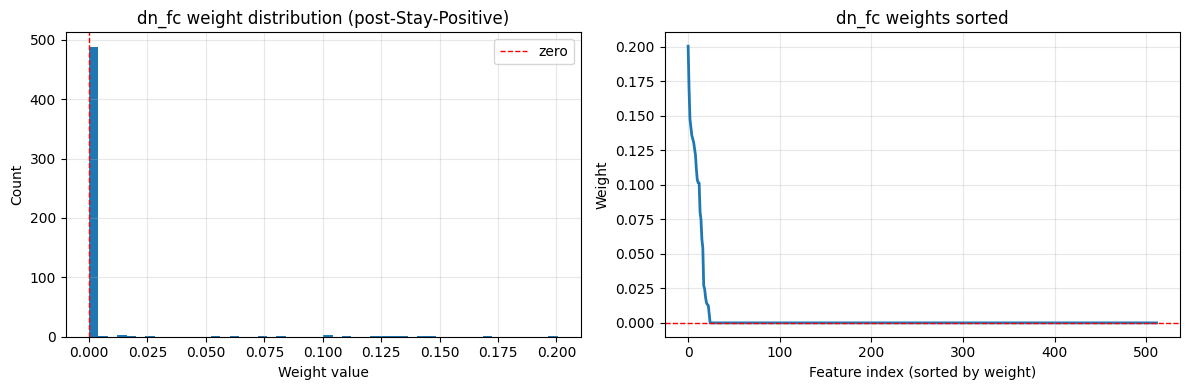

In [19]:
def inspect_final_layer(model):
    m = model.module if hasattr(model, 'module') else model
    w = m.dn_fc.weight.detach().cpu().numpy().flatten()
    b = m.dn_fc.bias.detach().cpu().item() if m.dn_fc.bias is not None else 0.0

    print(f'dn_fc weight stats:')
    print(f'  total entries        : {w.size}')
    print(f'  min / max / mean     : {w.min():.4f} / {w.max():.4f} / {w.mean():.4f}')
    print(f'  exactly zero         : {(w == 0).sum()}   ({100.0 * (w == 0).mean():.1f}%)')
    print(f'  strictly positive    : {(w > 0).sum()}')
    print(f'  bias                 : {b:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(w, bins=50)
    axes[0].axvline(0, color='red', linestyle='--', linewidth=1, label='zero')
    axes[0].set_xlabel('Weight value'); axes[0].set_ylabel('Count')
    axes[0].set_title('dn_fc weight distribution (post-Stay-Positive)')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    sorted_w = np.sort(w)[::-1]
    axes[1].plot(sorted_w, linewidth=2)
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[1].set_xlabel('Feature index (sorted by weight)'); axes[1].set_ylabel('Weight')
    axes[1].set_title('dn_fc weights sorted')
    axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


if 'sp_diff_net' in dir():
    inspect_final_layer(sp_diff_net)
else:
    print('Run the training cell first.')

## 12. Prediction Helper

Loads `staypositive_diffconvnet_best.pth` by default.

In [26]:
def predict_fake_image(image_path, model_path='staypositive_diffconvnet_best.pth', device=None):
    """Predict whether an image is Real or Fake using the StayPositive-DiffConvNet."""
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    if not os.path.exists(model_path):
        raise FileNotFoundError(f'Model not found: {model_path}')

    model = DiffConvNet(BaseNetwork(pretrained=False), n_iterations=N_DIFF)
    state = torch.load(model_path, map_location=device, weights_only=True)
    # Strip DataParallel "module." prefix if present.
    state = {k.replace('module.', '', 1): v for k, v in state.items()}
    model.load_state_dict(state)
    model.to(device)
    model.eval()

    if not os.path.exists(image_path):
        raise FileNotFoundError(f'Image not found: {image_path}')

    img = Image.open(image_path).convert('RGB')
    img_tensor = val_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(img_tensor)
        prob_fake  = torch.sigmoid(logits).item()
        pred_class = int(prob_fake >= 0.5)

    label = 'Fake' if pred_class == 1 else 'Real'
    print(f'Prediction: {label}  (prob_fake={prob_fake:.4f})')
    return {'prediction': pred_class, 'label': label,
            'confidence': prob_fake if pred_class == 1 else 1 - prob_fake,
            'prob_fake': prob_fake}


# Example usage:
predict_fake_image('/home/labpc/jepu20/Deep-Learning/frames/Validation/deepfake/007_132_sec16.jpg')

Prediction: Fake  (prob_fake=0.5306)


{'prediction': 1,
 'label': 'Fake',
 'confidence': 0.5305957794189453,
 'prob_fake': 0.5305957794189453}

## 13. Diffusion-States Visualisation

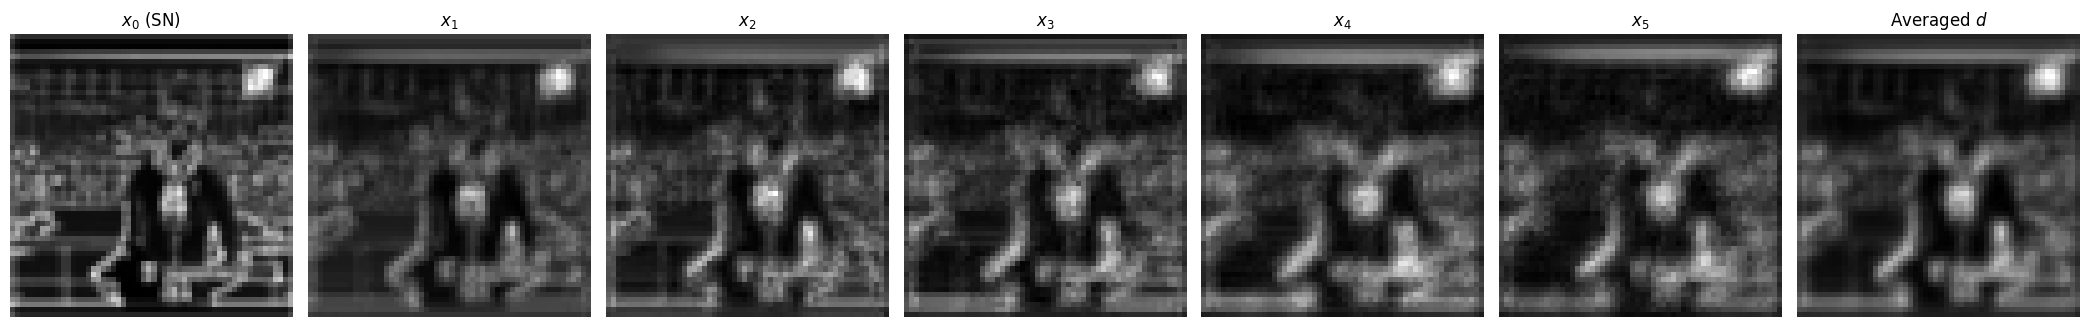

In [24]:
def visualize_diffusion_states(image_path, model_path='staypositive_diffconvnet_best.pth', device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = DiffConvNet(BaseNetwork(pretrained=False), n_iterations=N_DIFF)
    state = torch.load(model_path, map_location=device, weights_only=True)
    state = {k.replace('module.', '', 1): v for k, v in state.items()}
    model.load_state_dict(state)
    model.to(device)
    model.eval()

    img = Image.open(image_path).convert('RGB')
    img_tensor = val_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        x = model.sn(img_tensor)
        states = [x]
        m = model.module if hasattr(model, 'module') else model
        for layer in m.diff_net.diff_layers:
            x = layer(x)
            states.append(x)
        d = torch.stack(states, dim=0).mean(dim=0)

    num_plots = len(states) + 1
    fig, axes = plt.subplots(1, num_plots, figsize=(3 * num_plots, 4))
    for i, state in enumerate(states):
        fm = state.squeeze(0).mean(dim=0).cpu().numpy()
        axes[i].imshow(fm, cmap='gray')
        axes[i].set_title(f'$x_0$ (SN)' if i == 0 else f'$x_{i}$')
        axes[i].axis('off')
    d_map = d.squeeze(0).mean(dim=0).cpu().numpy()
    axes[-1].imshow(d_map, cmap='gray')
    axes[-1].set_title('Averaged $d$')
    axes[-1].axis('off')
    plt.tight_layout()
    plt.show()

visualize_diffusion_states('/home/labpc/jepu20/Deep-Learning/frames/Validation/deepfake/007_132_sec16.jpg')

## 14. Grad-CAM Interpretability

Compare Grad-CAM maps between `sp_diffconvnet_stage1_best.pth` (pre-Stay-Positive) and `staypositive_diffconvnet_best.pth` to see how the attention shifts after the last layer is forced to use only fake-image features.

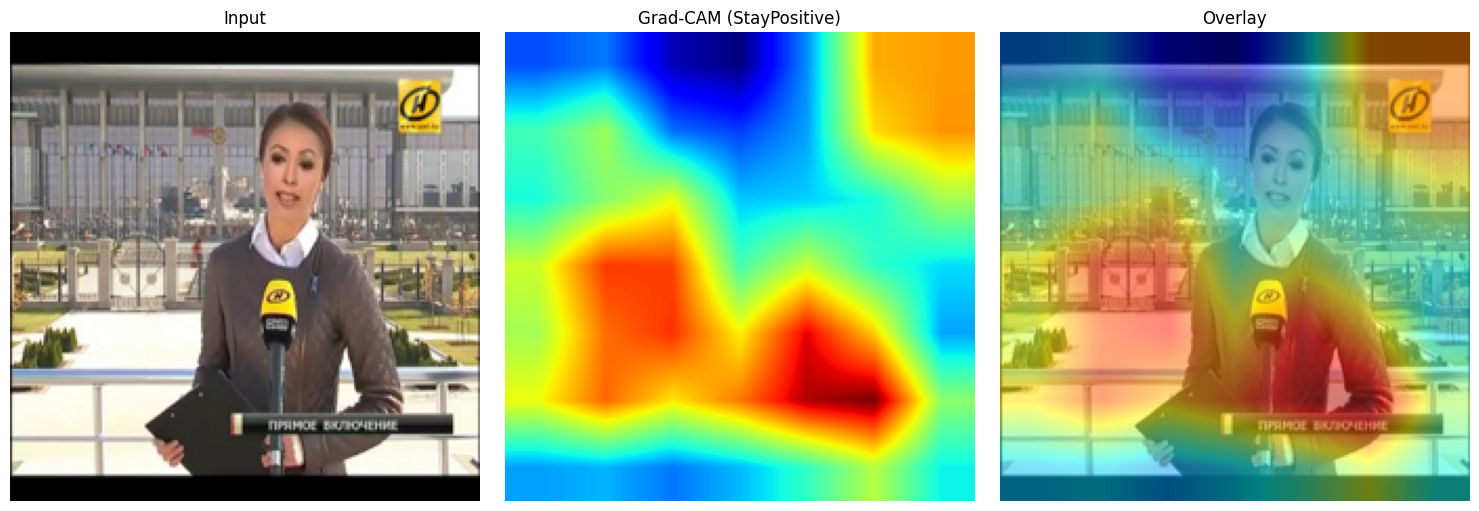

In [25]:
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x):
        self.model.eval()
        self.model.zero_grad()
        logits = self.model(x)
        logits[0].backward()
        grads = self.gradients.cpu().data.numpy()[0]
        acts  = self.activations.cpu().data.numpy()[0]
        weights = np.mean(grads, axis=(1, 2))
        cam = np.zeros(acts.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * acts[i]
        cam = np.maximum(cam, 0)
        if np.max(cam) != 0:
            cam /= np.max(cam)
        return cam


def generate_gradcam_plot(image_path, model_path='staypositive_diffconvnet_best.pth', device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = DiffConvNet(BaseNetwork(pretrained=False), n_iterations=N_DIFF)
    state = torch.load(model_path, map_location=device, weights_only=True)
    state = {k.replace('module.', '', 1): v for k, v in state.items()}
    model.load_state_dict(state)
    model.to(device)

    m = model.module if hasattr(model, 'module') else model
    grad_cam = GradCAM(model, m.dn_layer4)

    original_img = Image.open(image_path).convert('RGB')
    original_resized = original_img.resize((IMG_SIZE, IMG_SIZE))
    img_tensor = val_transform(original_img).unsqueeze(0).to(device)

    cam = grad_cam(img_tensor)
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    original_arr = np.array(original_resized)
    overlay = (original_arr * 0.5 + heatmap * 0.5).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original_arr);  axes[0].set_title('Input');      axes[0].axis('off')
    axes[1].imshow(cam_resized, cmap='jet'); axes[1].set_title('Grad-CAM (StayPositive)'); axes[1].axis('off')
    axes[2].imshow(overlay);       axes[2].set_title('Overlay');    axes[2].axis('off')
    plt.tight_layout()
    plt.show()

generate_gradcam_plot('/home/labpc/jepu20/Deep-Learning/frames/Validation/deepfake/007_132_sec16.jpg')

## 15. LIME Interpretability

In [17]:
# !pip install lime scikit-image

from lime import lime_image
from skimage.segmentation import mark_boundaries

def generate_lime_explanation(image_path, model_path='staypositive_diffconvnet_best.pth',
                               device=None, num_samples=1000):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = DiffConvNet(BaseNetwork(pretrained=False), n_iterations=N_DIFF)
    state = torch.load(model_path, map_location=device, weights_only=True)
    state = {k.replace('module.', '', 1): v for k, v in state.items()}
    model.load_state_dict(state)
    model.to(device)
    model.eval()

    def batch_predict(images):
        batch = torch.stack([
            val_transform(Image.fromarray(img.astype(np.uint8)))
            for img in images
        ], dim=0).to(device)
        with torch.no_grad():
            logits = model(batch)
            probs_fake = torch.sigmoid(logits).cpu().numpy()
            probs_real = 1.0 - probs_fake
        return np.vstack((probs_real, probs_fake)).T

    original_img     = Image.open(image_path).convert('RGB')
    original_resized = original_img.resize((IMG_SIZE, IMG_SIZE))
    img_np           = np.array(original_resized)

    explainer   = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        img_np, batch_predict, top_labels=1, hide_color=0, num_samples=num_samples
    )

    pred_label = explanation.top_labels[0]
    temp, mask = explanation.get_image_and_mask(
        pred_label, positive_only=True, num_features=5, hide_rest=False
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_np); axes[0].set_title('Original'); axes[0].axis('off')
    lbl_name = 'Fake' if pred_label == 1 else 'Real'
    axes[1].imshow(mark_boundaries(temp / 255.0, mask))
    axes[1].set_title(f'LIME — StayPositive (Predicted: {lbl_name})')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

# generate_lime_explanation('path/to/image.jpg')

/home/labpc/jepu20/Deep-Learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 16. Summary of artefacts produced

After a full run this notebook leaves the following files in the working directory:

| File | Phase | What it is |
|---|---|---|
| `sp_base_net_best.pth` | 1 | Best ResNet18 baseline |
| `sp_diffconvnet_stage1_best.pth` | 2 | Best stage-1 DiffConvNet (pre-Stay-Positive) |
| `sp_diffconvnet_stage1_final.pth` | 2 | Final stage-1 DiffConvNet (last epoch) |
| **`staypositive_diffconvnet_best.pth`** | 3 | **Final model — DiffConvNet with Stay-Positive last layer (use this for inference)** |
| `staypositive_diffconvnet_final.pth` | 3 | Last-epoch Stay-Positive model |
| `sp_checkpoints/*` | all | Periodic intermediate checkpoints |

Keep `sp_diffconvnet_stage1_best.pth` around — comparing it side-by-side with `staypositive_diffconvnet_best.pth` on test sets that include compressed / resized / inpainted images is how you measure whether Stay-Positive actually helped, per the experiments in Section 5 of the paper.